In [1]:
import os
import json
import urllib.request
import zipfile

from dataclasses import dataclass
from collections import Counter

import nltk
import torch
import torchmetrics
import gensim.downloader as api

import numpy as np
import pandas as pd
import seaborn as sns

from torch import nn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from matplotlib import pyplot as plt

/Users/anas/academy/worshop_3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Setup

- **Word level vocab is generated from the cleaned toxic tweets dataset**

In [2]:
data_dir = os.path.join(os.curdir, "data")
dataset_path = os.path.join(data_dir, "clean-toxic-tweets.csv")

dataset = pd.read_csv(filepath_or_buffer=dataset_path)

# Drop rows with empty clean_text
dataset = dataset.dropna(subset=["clean_text"]).reset_index(drop=True)

print(f"Dataset shape: {dataset.shape}")
dataset.head()

Dataset shape: (28862, 8)


,id,label,tweet,label_name,word_count,char_count,clean_text,clean_stemmed
0,1,0,@user when a father is dysfunctional and is s...,non-toxic,21,102,dysfunctional selfish drags dysfunction,dysfunct selfish drag dysfunct
1,2,0,@user @user thanks for #lyft credit i can't us...,non-toxic,22,122,credit cant cause dont offer wheelchair vans pdx,credit cant caus dont offer wheelchair van pdx
2,3,0,bihday your majesty,non-toxic,5,21,majesty,majesti
3,5,0,factsguide: society now #motivation,non-toxic,8,39,factsguide society,factsguid societi
4,6,0,[2/2] huge fan fare and big talking before the...,non-toxic,21,116,huge fan fare talking chaos disputes,huge fan fare talk chao disput


In [3]:
tweets = dataset["clean_text"].astype(str).tolist()
labels = dataset["label"].tolist()

print(f"Total tweets: {len(tweets)}")
print(f"Label distribution: {Counter(labels)}")

Total tweets: 28862
Label distribution: Counter({0: 26672, 1: 2190})


In [4]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")

Device: mps


# Train / Test Split (shared across all approaches)

In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    tweets, labels, stratify=labels, test_size=0.15, random_state=42
)

print(f"Train size: {len(X_train_text)}, Test size: {len(X_test_text)}")

Train size: 24532, Test size: 4330


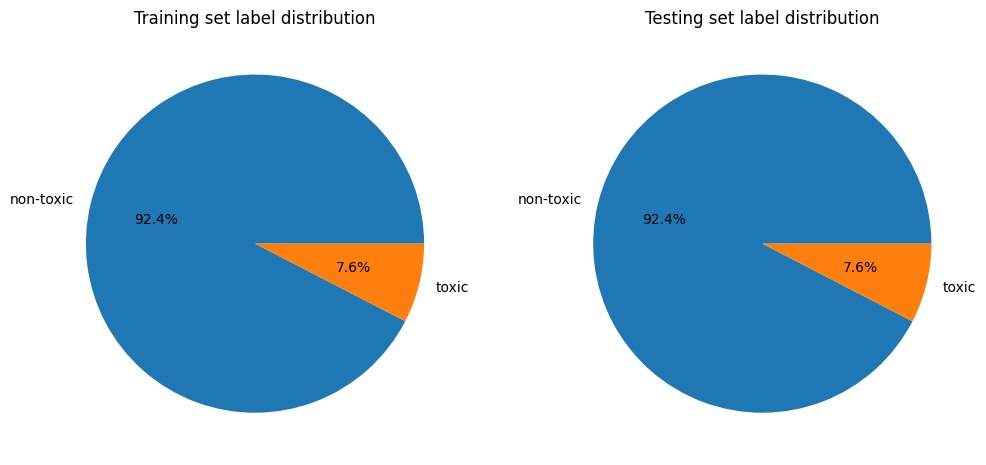

In [6]:
fig, (ax1, ax2) = plt.subplots(figsize=(12, 10), ncols=2)

train_dist = Counter(y_train)
test_dist = Counter(y_test)
label_names = ["non-toxic", "toxic"]

ax1.pie(x=[train_dist[0], train_dist[1]], labels=label_names, autopct='%1.1f%%')
ax2.pie(x=[test_dist[0], test_dist[1]], labels=label_names, autopct='%1.1f%%')

ax1.set_title("Training set label distribution")
ax2.set_title("Testing set label distribution")

plt.show()

# Part 1: Bag of Words (BoW)

Bag of Words converts each document into a vector of word counts. Each position in the vector represents a unique word in the vocabulary, and the value is how many times that word appears in the document.

**Pros:** Simple, fast, easy to understand  
**Cons:** Loses word order, ignores context, sparse representation

In [7]:
# Vectorize text using Bag of Words
bow_vectorizer = CountVectorizer(max_features=5000)

X_train_bow = bow_vectorizer.fit_transform(X_train_text)
X_test_bow = bow_vectorizer.transform(X_test_text)

print(f"BoW feature shape: {X_train_bow.shape}")
print(f"Sample feature names: {bow_vectorizer.get_feature_names_out()[:10]}")

BoW feature shape: (24532, 5000)
Sample feature names: ['abandoned' 'abc' 'ability' 'able' 'absolute' 'absolutely' 'abt' 'abuse'
 'acc' 'accept']


## Train Logistic Regression with BoW

In [8]:
# Train Logistic Regression on BoW features
bow_model = LogisticRegression(max_iter=1000, class_weight="balanced")
bow_model.fit(X_train_bow, y_train)

# Evaluate
bow_preds = bow_model.predict(X_test_bow)
bow_f1 = f1_score(y_test, bow_preds, average="binary")

print(f"BoW + Logistic Regression F1 Score: {bow_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, bow_preds, target_names=["non-toxic", "toxic"]))

BoW + Logistic Regression F1 Score: 0.4589

Classification Report:
              precision    recall  f1-score   support

   non-toxic       0.97      0.91      0.94      4001
       toxic       0.37      0.61      0.46       329

    accuracy                           0.89      4330
   macro avg       0.67      0.76      0.70      4330
weighted avg       0.92      0.89      0.90      4330



# Part 2: TF-IDF (Term Frequency - Inverse Document Frequency)

TF-IDF improves on BoW by weighting words based on how important they are. Words that appear frequently in one document but rarely across all documents get higher scores.

- **TF (Term Frequency):** How often a word appears in a document
- **IDF (Inverse Document Frequency):** Penalises words that appear in many documents (e.g., "the", "is")

**Pros:** Better than raw counts, downweights common words  
**Cons:** Still loses word order, still sparse

In [9]:
# Vectorize text using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(f"TF-IDF feature shape: {X_train_tfidf.shape}")
print(f"Sample feature names: {tfidf_vectorizer.get_feature_names_out()[:10]}")

TF-IDF feature shape: (24532, 5000)
Sample feature names: ['abandoned' 'abc' 'ability' 'able' 'absolute' 'absolutely' 'abt' 'abuse'
 'acc' 'accept']


## Train Logistic Regression with TF-IDF

In [10]:
# Train Logistic Regression on TF-IDF features
tfidf_model = LogisticRegression(max_iter=1000, class_weight="balanced")
tfidf_model.fit(X_train_tfidf, y_train)

# Evaluate
tfidf_preds = tfidf_model.predict(X_test_tfidf)
tfidf_f1 = f1_score(y_test, tfidf_preds, average="binary")

print(f"TF-IDF + Logistic Regression F1 Score: {tfidf_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, tfidf_preds, target_names=["non-toxic", "toxic"]))

TF-IDF + Logistic Regression F1 Score: 0.4673

Classification Report:
              precision    recall  f1-score   support

   non-toxic       0.97      0.90      0.94      4001
       toxic       0.36      0.66      0.47       329

    accuracy                           0.89      4330
   macro avg       0.67      0.78      0.70      4330
weighted avg       0.92      0.89      0.90      4330



# Part 3: Pretrained Embeddings (GloVe) + RNN

Instead of learning embeddings from scratch, we use **GloVe** (Global Vectors for Word Representation) — pretrained word vectors trained on a massive corpus. Each word is represented as a dense vector that captures semantic meaning.

We load the pretrained vectors, build an embedding matrix for our vocabulary, and feed it into a **Bidirectional LSTM** for classification.

**Pros:** Captures semantic meaning, dense representation, leverages external knowledge  
**Cons:** Fixed vocabulary (OOV words get zero vectors), slower to train

## Load GloVe Pretrained Embeddings

In [11]:
# Load GloVe embeddings using gensim (downloads ~66MB)
# glove-twitter-100 is trained on Twitter data with 100-dimensional vectors
glove = api.load("glove-twitter-100")

EMBEDDING_DIM = glove.vector_size
print(f"GloVe embedding dimension: {EMBEDDING_DIM}")
print(f"GloVe vocabulary size: {len(glove)}")
print(f"Example - vector for 'good': {glove['good'][:5]}...")

[==================================================] 100.0% 387.1/387.1MB downloaded

GloVe embedding dimension: 100
GloVe vocabulary size: 1193514
Example - vector for 'good': [ 0.091552  0.093336 -0.028113  0.3699    0.18956 ]...
GloVe embedding dimension: 100
GloVe vocabulary size: 1193514
Example - vector for 'good': [ 0.091552  0.093336 -0.028113  0.3699    0.18956 ]...


## Build Vocabulary and Embedding Matrix

In [12]:
# Build word-to-index vocab from training data
PAD_TOKEN = "[PAD]"
OOV_TOKEN = "[OOV]"
MIN_FREQ = 2

all_words = [word for tweet in X_train_text for word in tweet.split(" ") if word]
word_counts = Counter(all_words)

word2idx = {PAD_TOKEN: 0, OOV_TOKEN: 1}
idx = 2
for word, count in word_counts.items():
    if count >= MIN_FREQ:
        word2idx[word] = idx
        idx += 1

VOCAB_SIZE = len(word2idx)
print(f"Vocab size: {VOCAB_SIZE}")

# Build embedding matrix from GloVe
embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM))
found = 0
for word, i in word2idx.items():
    if word in glove:
        embedding_matrix[i] = glove[word]
        found += 1

print(f"Words found in GloVe: {found}/{VOCAB_SIZE} ({100*found/VOCAB_SIZE:.1f}%)")

Vocab size: 9047
Words found in GloVe: 8624/9047 (95.3%)


## Tokenize and Pad Sequences

In [13]:
OOV_INDEX = word2idx[OOV_TOKEN]
PAD_INDEX = word2idx[PAD_TOKEN]

def tokenize_tweets(tweets_list):
    return [[word2idx.get(token, OOV_INDEX) for token in tweet.split(" ") if token] for tweet in tweets_list]

train_tokens = tokenize_tweets(X_train_text)
test_tokens = tokenize_tweets(X_test_text)

# Filter out empty sequences
MAX_LENGTH = int(np.percentile([len(t) for t in train_tokens if len(t) > 0], q=99))
print(f"Max sequence length (99th percentile): {MAX_LENGTH}")

# Pad sequences
X_train_rnn = nn.utils.rnn.pad_sequence(
    [torch.tensor(t[:MAX_LENGTH]) for t in train_tokens if len(t) > 0],
    batch_first=True,
    padding_value=PAD_INDEX
)
X_test_rnn = nn.utils.rnn.pad_sequence(
    [torch.tensor(t[:MAX_LENGTH]) for t in test_tokens if len(t) > 0],
    batch_first=True,
    padding_value=PAD_INDEX
)

# Filter labels to match (remove empty sequences)
y_train_rnn = torch.tensor([l for t, l in zip(train_tokens, y_train) if len(t) > 0])
y_test_rnn = torch.tensor([l for t, l in zip(test_tokens, y_test) if len(t) > 0])

print(f"Train shape: {X_train_rnn.shape}, Test shape: {X_test_rnn.shape}")

Max sequence length (99th percentile): 11
Train shape: torch.Size([24532, 11]), Test shape: torch.Size([4330, 11])
Train shape: torch.Size([24532, 11]), Test shape: torch.Size([4330, 11])


In [14]:
BATCH_SIZE = 32

train_dataset = torch.utils.data.TensorDataset(X_train_rnn, y_train_rnn)
test_dataset = torch.utils.data.TensorDataset(X_test_rnn, y_test_rnn)

train_dataloader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## RNN Model with Pretrained Embeddings (Frozen)

The embedding layer is initialised with the GloVe vectors and **frozen** (`freeze=True`) so it is not updated during training. The model only learns the LSTM and classification layers.

In [15]:
class ToxicityClassifierGloVe(nn.Module):
    def __init__(
        self, 
        pretrained_embeddings: np.ndarray,
        latent_dim: int,
        num_classes: int = 2,
        dropout: float = 0.3,
        freeze_embeddings: bool = True
    ):
        super().__init__()
        vocab_size, embedding_dim = pretrained_embeddings.shape
        self.latent_dim = latent_dim
        
        # Load pretrained embeddings into the embedding layer
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(pretrained_embeddings),
            freeze=freeze_embeddings,  # Don't update GloVe vectors during training
            padding_idx=0
        )
        
        self.rnn = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=self.latent_dim,
            batch_first=True,
            num_layers=1,
            bidirectional=True
        )
        
        self.fc1 = nn.Linear(in_features=self.latent_dim * 2, out_features=num_classes)
        self.dropout = nn.Dropout(p=dropout)
    
    def forward(self, x):
        # x = (batch_size, sequence_length) 
        embeddings = self.embedding(x)       
        embeddings = self.dropout(embeddings)
        # embeddings = (batch_size, sequence_length, embedding_dim)
        
        hidden_states, (last_hidden_state, last_cell_state) = self.rnn(embeddings)
        
        # Concatenate forward and backward last hidden states
        output = torch.concat([last_hidden_state[-1,:,:], last_hidden_state[-2,:,:]], dim=-1) 
        output = self.dropout(output)
        output = self.fc1(output)      
        
        return output

In [16]:
LATENT_DIM = 64
DROPOUT = 0.3

rnn_model = ToxicityClassifierGloVe(
    pretrained_embeddings=embedding_matrix,
    latent_dim=LATENT_DIM,
    num_classes=2,
    dropout=DROPOUT,
    freeze_embeddings=True
).to(device)

print(rnn_model)
print(f"\nTrainable parameters: {sum(p.numel() for p in rnn_model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

ToxicityClassifierGloVe(
  (embedding): Embedding(9047, 100, padding_idx=0)
  (rnn): LSTM(100, 64, batch_first=True, bidirectional=True)
  (fc1): Linear(in_features=128, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

Trainable parameters: 85,250
Total parameters: 989,950


## Training

In [17]:
EPOCHS = 20
LR = 1e-3

optimizer = torch.optim.Adam(params=rnn_model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

train_metric = torchmetrics.F1Score(task="binary").to(device)
val_metric = torchmetrics.F1Score(task="binary").to(device)

@dataclass
class EpochResult:
    epoch: int
    training_loss: float
    validation_loss: float
    training_f1: float
    validation_f1: float
    
    def log(self) -> None:
        print(f"Epoch {self.epoch + 1:2d}: Train Loss: {self.training_loss:.4f}  Val Loss: {self.validation_loss:.4f} | Train F1: {self.training_f1:.4f}  Val F1: {self.validation_f1:.4f}")

In [ ]:
history = []

for epoch in range(EPOCHS):
    epoch_train_loss = 0
    epoch_val_loss = 0
    train_metric.reset()
    val_metric.reset()
    
    # Training
    rnn_model.train()
    for batch in train_dataloader:
        optimizer.zero_grad()
        inputs, target = batch
        inputs, target = inputs.to(device), target.to(device)
        
        predictions = rnn_model(inputs)
        loss = criterion(predictions, target)
        preds = torch.argmax(predictions, dim=-1)
        train_metric(preds, target)
        
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    epoch_train_f1 = train_metric.compute().item()
    
    # Validation
    rnn_model.eval()
    with torch.no_grad():
        for batch in test_dataloader:
            inputs, target = batch
            inputs, target = inputs.to(device), target.to(device)
            
            predictions = rnn_model(inputs)
            loss = criterion(predictions, target)
            preds = torch.argmax(predictions, dim=-1)
            val_metric(preds, target)
            epoch_val_loss += loss.item()
        
        epoch_val_f1 = val_metric.compute().item()
    
    epoch_train_loss /= len(train_dataloader)
    epoch_val_loss /= len(test_dataloader)
    
    result = EpochResult(
        epoch=epoch,
        training_loss=epoch_train_loss,
        validation_loss=epoch_val_loss,
        training_f1=epoch_train_f1,
        validation_f1=epoch_val_f1
    )
    history.append(result)
    result.log()

Epoch  1: Train Loss: 0.2242  Val Loss: 0.2029 | Train F1: 0.1937  Val F1: 0.2687
Epoch  2: Train Loss: 0.1987  Val Loss: 0.2000 | Train F1: 0.3326  Val F1: 0.3210
Epoch  2: Train Loss: 0.1987  Val Loss: 0.2000 | Train F1: 0.3326  Val F1: 0.3210
Epoch  3: Train Loss: 0.1860  Val Loss: 0.1913 | Train F1: 0.3976  Val F1: 0.4228
Epoch  3: Train Loss: 0.1860  Val Loss: 0.1913 | Train F1: 0.3976  Val F1: 0.4228
Epoch  4: Train Loss: 0.1742  Val Loss: 0.1861 | Train F1: 0.4486  Val F1: 0.3944
Epoch  4: Train Loss: 0.1742  Val Loss: 0.1861 | Train F1: 0.4486  Val F1: 0.3944
Epoch  5: Train Loss: 0.1639  Val Loss: 0.1813 | Train F1: 0.4914  Val F1: 0.4708
Epoch  5: Train Loss: 0.1639  Val Loss: 0.1813 | Train F1: 0.4914  Val F1: 0.4708
Epoch  6: Train Loss: 0.1545  Val Loss: 0.1844 | Train F1: 0.5416  Val F1: 0.4454
Epoch  6: Train Loss: 0.1545  Val Loss: 0.1844 | Train F1: 0.5416  Val F1: 0.4454
Epoch  7: Train Loss: 0.1479  Val Loss: 0.1828 | Train F1: 0.5684  Val F1: 0.4584
Epoch  7: Train 

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(figsize=(15, 6), ncols=2)

epochs_range = range(1, EPOCHS + 1)
train_losses = [r.training_loss for r in history]
val_losses = [r.validation_loss for r in history]
train_f1s = [r.training_f1 for r in history]
val_f1s = [r.validation_f1 for r in history]

ax1.plot(epochs_range, train_losses, label="Training")
ax1.plot(epochs_range, val_losses, label="Validation")
ax1.set_title("Loss", fontsize=15)
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(epochs_range, train_f1s, label="Training")
ax2.plot(epochs_range, val_f1s, label="Validation")
ax2.set_title("F1 Score", fontsize=15)
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

# Summary: Comparison of Approaches

| Approach | Encoding | Classifier | Captures Word Order? |
|----------|----------|------------|---------------------|
| **Part 1** | Bag of Words | Logistic Regression | ❌ No |
| **Part 2** | TF-IDF | Logistic Regression | ❌ No |
| **Part 3** | GloVe Embeddings | Bi-LSTM (RNN) | ✅ Yes ( because of Rnn) |

In [ ]:
# Final comparison
glove_f1 = val_f1s[-1]

print("=" * 50)
print("F1 Score Comparison (on test set)")
print("=" * 50)
print(f"  Bag of Words + Logistic Regression:  {bow_f1:.4f}")
print(f"  TF-IDF + Logistic Regression:        {tfidf_f1:.4f}")
print(f"  GloVe + Bi-LSTM (RNN):               {glove_f1:.4f}")
print("=" * 50)

# Bar chart comparison
methods = ["BoW + LR", "TF-IDF + LR", "GloVe + BiLSTM"]
scores = [bow_f1, tfidf_f1, glove_f1]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(methods, scores, color=["#4CAF50", "#2196F3", "#FF9800"])
ax.set_ylabel("F1 Score")
ax.set_title("Model Comparison - F1 Score on Test Set", fontsize=14)
ax.set_ylim(0, 1)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01, 
            f'{score:.4f}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()